Uniform and inverse CDF sampling

In [1]:
import math
import random 
def sample_uniform(a,b):
    return a+(b-a) *random.random()

def sample_exponential_inverse_cdf(lam):
    u=random.random()
    return -math.log(u)/lam 

In [4]:

print("Uniform samples:", [round(sample_uniform(2, 5),4) for _ in range(5)])


print("Exponential samples:", [round(sample_exponential_inverse_cdf(1.5), 4) for _ in range(5)])

Uniform samples: [4.5683, 2.0026, 3.2759, 3.8917, 3.1714]
Exponential samples: [0.1479, 0.2774, 0.9087, 0.6562, 0.1382]


Rejection sampling

In [8]:
def rejection_sampling(target_pdf,proposal_sample,proposal_pdf,M):
    while True:
        x=proposal_sample()
        u = random.random()
        if u < target_pdf(x) / (M * proposal_pdf(x)):
            return x

In [9]:
def target_pdf(x):
    # Unnormalized standard normal, only on [-3, 3]
    return math.exp(-x * x / 2)

def proposal_sample():
    return random.uniform(-3, 3)

def proposal_pdf(x):
    # Uniform on [-3, 3] has density 1/6
    return 1.0 / 6.0

# M must satisfy p(x) <= M * q(x) for all x in [-3,3].
# max p(x) = 1 (at x=0), q = 1/6, so M >= 6.
M = 6.0

samples = [rejection_sampling(target_pdf, proposal_sample, proposal_pdf, M)
           for _ in range(10_000)]

print("Mean:", sum(samples) / len(samples))   # ~ 0
print("Var :", sum(x*x for x in samples)/len(samples))  # ~ 1

Mean: -0.0033348645196623478
Var : 0.969391150737075


Accepted: 10000
Rejected: 14150
Acceptance rate: 0.414   (theory = 1/M = 0.167)
Empirical mean: 0.0024   (theory = 0)
Empirical var : 0.9631   (theory = 1)


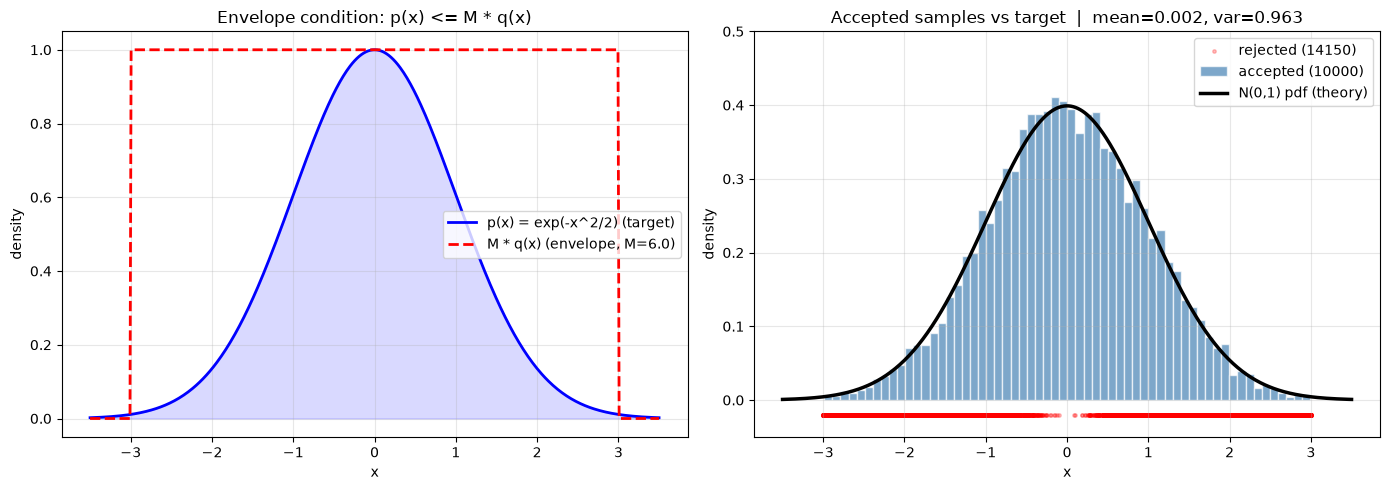

In [ ]:
import math
import random
import numpy as np
import matplotlib
matplotlib.rcParams['text.usetex'] = False   # ensure mathtext, not real LaTeX
import matplotlib.pyplot as plt

# ---------- Target: standard normal (unnormalized) ----------
def target_pdf(x):
    x = np.asarray(x, dtype=float)
    return np.exp(-x * x / 2)

# ---------- Proposal: Uniform on [-3, 3] ----------
def proposal_sample():
    return random.uniform(-3, 3)

def proposal_pdf(x):
    x = np.asarray(x, dtype=float)
    return np.where((x >= -3) & (x <= 3), 1.0 / 6.0, 0.0)

M = 6.0   # MUST be >= sup p(x)/q(x) = 6

# ---------- Rejection sampler with history ----------
def rejection_sampling_verbose(n_accept, target_pdf, proposal_sample, proposal_pdf, M):
    accepted, rejected = [], []
    while len(accepted) < n_accept:
        x = proposal_sample()
        u = random.random()
        p_x = float(target_pdf(x))
        q_x = float(proposal_pdf(x))
        if u < p_x / (M * q_x):
            accepted.append(x)
        else:
            rejected.append(x)
    return accepted, rejected

# ---------- Run ----------
random.seed(42)
N = 10_000
accepted, rejected = rejection_sampling_verbose(N, target_pdf, proposal_sample, proposal_pdf, M)

accepted = np.array(accepted)
rejected = np.array(rejected)

emp_mean = accepted.mean()
emp_var  = accepted.var()
acc_rate = N / (N + len(rejected))

print(f"Accepted: {N}")
print(f"Rejected: {len(rejected)}")
print(f"Acceptance rate: {acc_rate:.3f}   (theory = 1/M = {1/M:.3f})")
print(f"Empirical mean: {emp_mean:.4f}   (theory = 0)")
print(f"Empirical var : {emp_var:.4f}   (theory = 1)")

# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ===== LEFT: Envelope =====
ax = axes[0]
xs = np.linspace(-3.5, 3.5, 500)
ax.plot(xs, target_pdf(xs), 'b-', lw=2, label='p(x) = exp(-x^2/2) (target)')
ax.plot(xs, M * proposal_pdf(xs), 'r--', lw=2, label=f'M * q(x) (envelope, M={M})')
ax.fill_between(xs, 0, target_pdf(xs), color='blue', alpha=0.15)
ax.set_title('Envelope condition: p(x) <= M * q(x)')
ax.set_xlabel('x'); ax.set_ylabel('density')
ax.legend(); ax.grid(alpha=0.3)

# ===== RIGHT: Histogram of accepted =====
ax = axes[1]
ax.scatter(rejected, np.full_like(rejected, -0.02),
           s=6, color='red', alpha=0.25, label=f'rejected ({len(rejected)})')
ax.hist(accepted, bins=60, density=True, color='steelblue',
        alpha=0.7, edgecolor='white', label=f'accepted ({len(accepted)})')

norm_const = math.sqrt(2 * math.pi)
ax.plot(xs, np.exp(-xs**2 / 2) / norm_const, 'k-', lw=2.5,
        label='N(0,1) pdf (theory)')

ax.set_title(f'Accepted samples vs target  |  mean={emp_mean:.3f}, var={emp_var:.3f}')
ax.set_xlabel('x'); ax.set_ylabel('density')
ax.set_ylim(-0.05, 0.5)
ax.legend(loc='upper right'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Importance sampling

In [14]:
def importance_sampling_estimate(f, target_pdf, proposal_pdf, proposal_sample, n):
    total = 0
    for _ in range(n):
        x = proposal_sample()
        w = target_pdf(x) / proposal_pdf(x)
        total += f(x) * w
    return total / n

In [15]:
def target_pdf(x):
    # Standard normal N(0,1)
    return math.exp(-x * x / 2) / math.sqrt(2 * math.pi)

def proposal_sample():
    # Uniform on [-3, 3]
    return random.uniform(-3, 3)

def proposal_pdf(x):
    if -3 <= x <= 3:
        return 1.0 / 6.0
    return 0.0

In [16]:
f = lambda x: x * x

In [17]:
random.seed(0)
n = 200_000
estimate = importance_sampling_estimate(f, target_pdf, proposal_pdf, proposal_sample, n)

print(f"Importance sampling estimate of E[X^2]: {estimate:.6f}")
print(f"True value (standard normal):           1.000000")

Importance sampling estimate of E[X^2]: 0.970634
True value (standard normal):           1.000000


Monte Carlo estimation of pi

In [18]:
def monte_carlo_pi(n):
    inside = 0
    for _ in range(n):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)
        if x*x + y*y <= 1:
            inside += 1
    return 4 * inside / n

In [19]:
random.seed(0)
for n in [100, 1_000, 10_000, 100_000, 1_000_000]:
    est = monte_carlo_pi(n)
    err = abs(est - math.pi)
    # 95% CI half-width: 1.96 * SE
    se = 4 * math.sqrt((math.pi/4) * (1 - math.pi/4) / n)
    print(f"n={n:>8}  π̂ = {est:.6f}  |error| = {err:.6f}  ±{1.96*se:.6f}")

n=     100  π̂ = 3.280000  |error| = 0.138407  ±0.321868
n=    1000  π̂ = 3.020000  |error| = 0.121593  ±0.101784
n=   10000  π̂ = 3.144800  |error| = 0.003207  ±0.032187
n=  100000  π̂ = 3.130560  |error| = 0.011033  ±0.010178
n= 1000000  π̂ = 3.141780  |error| = 0.000187  ±0.003219
